This notebook is the most up-to-date piezo characterization data, taken december  15th, 2025. Following analysis includes the peizo's input voltge to stroke disatnce relation. This is for the disk piezo with center frequency ~109 kHz.

In [1]:

'''
scan details:

109Hz driving with sine wave

'''


import sys
sys.path.append("../")
from analysis import System as syst
import matplotlib.pyplot as plt
import math
import numpy as np
from scipy.signal import periodogram, welch, find_peaks
from scipy.optimize import curve_fit as fit
f_guess = 1.0955e5
def signal(t, a, b, c):
    '''
    sine  interference signal that the psd is fitted to
    '''
    return a * np.sin(2*np.pi * f_guess * t + b) + c
def find_nearest(array, value):
    '''
    finding the value in array closest to input value
    '''
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]
def find_idx(array, value):
    '''
    finding the index of value in array closest to input value
    '''
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx
def pp(arr, d, i):
    '''
    applying time constraints and linear detrend to psd scan
    '''
    arr.set_data(ind = i)
    d.apply("time_gate", tmin = 0, tmax = 5e-4, inplace = True)
    d.apply("detrend", mode = "linear", inplace = True) # accounts for linear signal drift

In [5]:
# 28 time collections in each folder, there are 10 folders to go through, 280 piezo objects
piezo_objects=[]
usable_scans = list(range(29))
num_folders = [1,2,3,4,5,6,7,8,9,10]
usable_scans.sort() #ordering smallest to largest
num_scans = len(usable_scans)
rows  = math.ceil(len(usable_scans)/4) # for graphing subplots easier

# creating a piezo object, see System() class in analysis.py for details
piezo = syst(
    "piezo",
    # CHNAGE LINK HERE
    [r"C:\Users\sl57562\The University of Texas at Austin\Acoustic + Calcium - Documents\Acoustic\Piezo_Characterization_Data_12-15-25\stroke_dist_"+str(1)+"vpp_109kHz/iter_"+str(x)+".tdms" for x in range(29)],
    channel="X",
    set_data=True
)
# confirming files in piezo object
#print(piezo.get_data())
#print(usable_scans)

In [9]:
# decent files: 32, 31, 28, 27, 26, 25, 22, 21, 20, 19, 17, 16, 15, 13

In [6]:
# this block is a peak finding method. find_peaks gets the max psd index within bounds, then parabolic_interp makes parabolic fit 
# to smooth the discrete data

def parabolic_interp(freqs, Pxx, peak_idx):
    # this is a 3 point parabolic fit, needed because real peak might not be exactly on a periodogram bin
    # turns out its not really needed, find_peaks gets within +/- 5Hz on its own

    # cannot fit at ends of data
    if peak_idx ==0 or peak_idx ==len(Pxx)-1:
        return freqs[peak_idx]

    #extracting psd values
    y0 = Pxx[peak_idx-1]
    y1 = Pxx[peak_idx]
    y2 = Pxx[peak_idx+1]
    # solve for the vertix of the parabola 
    denom = y0-2*y1+y2
    if denom ==0:
        return freqs[peak_idx] #division by 0
    vx = 1/2 * (y0-y2) 

    # offset bin formula
    offset_from_central_bin = vx/denom * (freqs[1]-freqs[0])
    df = freqs[1]-freqs[0]

    return freqs[peak_idx] + offset_from_central_bin
    
    
def find_driving_freq_peaks(Pxx,f,fs,f_guess,window_hz,nfft):
    
    fmin = max(0,f_guess-window_hz)
    fmax = min(fs/2,f_guess+window_hz)
    
    min_idx = np.searchsorted(f,1.08e5)
    max_idx = np.searchsorted(f,1.10e5)
   
    f_band = f[min_idx:max_idx]
    P_band = Pxx[min_idx:max_idx]
  
    peak_idxs,properties = find_peaks(P_band, prominence=np.max(P_band)*.03,height=np.max(P_band) * 0.02)    
    #print(f_band[find_idx(P_band,np.max(P_band))])

    if len(peak_idxs) == 0:
        # this means that the global maximum is in the band 
        peak_idx = np.argmax(P_band)
    else:
        biggest = np.argmax(properties["prominences"]) 
        peak_idx = peak_idxs[biggest] #return the index with the largest prominance, so the most dominate curve

    # where is the actual peak globally
    global_max_idx = min_idx + peak_idx
    
    #f_refined = f[global_max_idx]
    
    f_refined = parabolic_interp(f,Pxx,global_max_idx)

    return f_refined,f,Pxx
f_sum = 0   
print("Finding average driving frequency...")
for i, d in enumerate(piezo.get_data()):
    
    pp(piezo,d,i)
    fs = d.r
    f, x1 = periodogram(d.collection[0].x, piezo.get_data()[i].r,nfft=int(fs)//2)
    avg = np.array(x1)
    f, x2 = periodogram(d.collection[1].x, piezo.get_data()[i].r, nfft= int(fs)//2)
    
    x = (np.array(x2)+avg)/2
    
    f_estimation, f_arr, Pxx = find_driving_freq_peaks(x,f,fs,f_guess, window_hz = .1e5,nfft=int(fs))
    f_sum += f_estimation
    #print(f"File{usable_scans[i]}: driving frequency = {f_estimation:.3f} Hz")
f_avg = f_sum / len(piezo.get_data())
print(f"AVERAGE DRIVING FREQ = {f_avg:.3f} Hz")  
    

Finding average driving frequency...
AVERAGE DRIVING FREQ = 109023.450 Hz


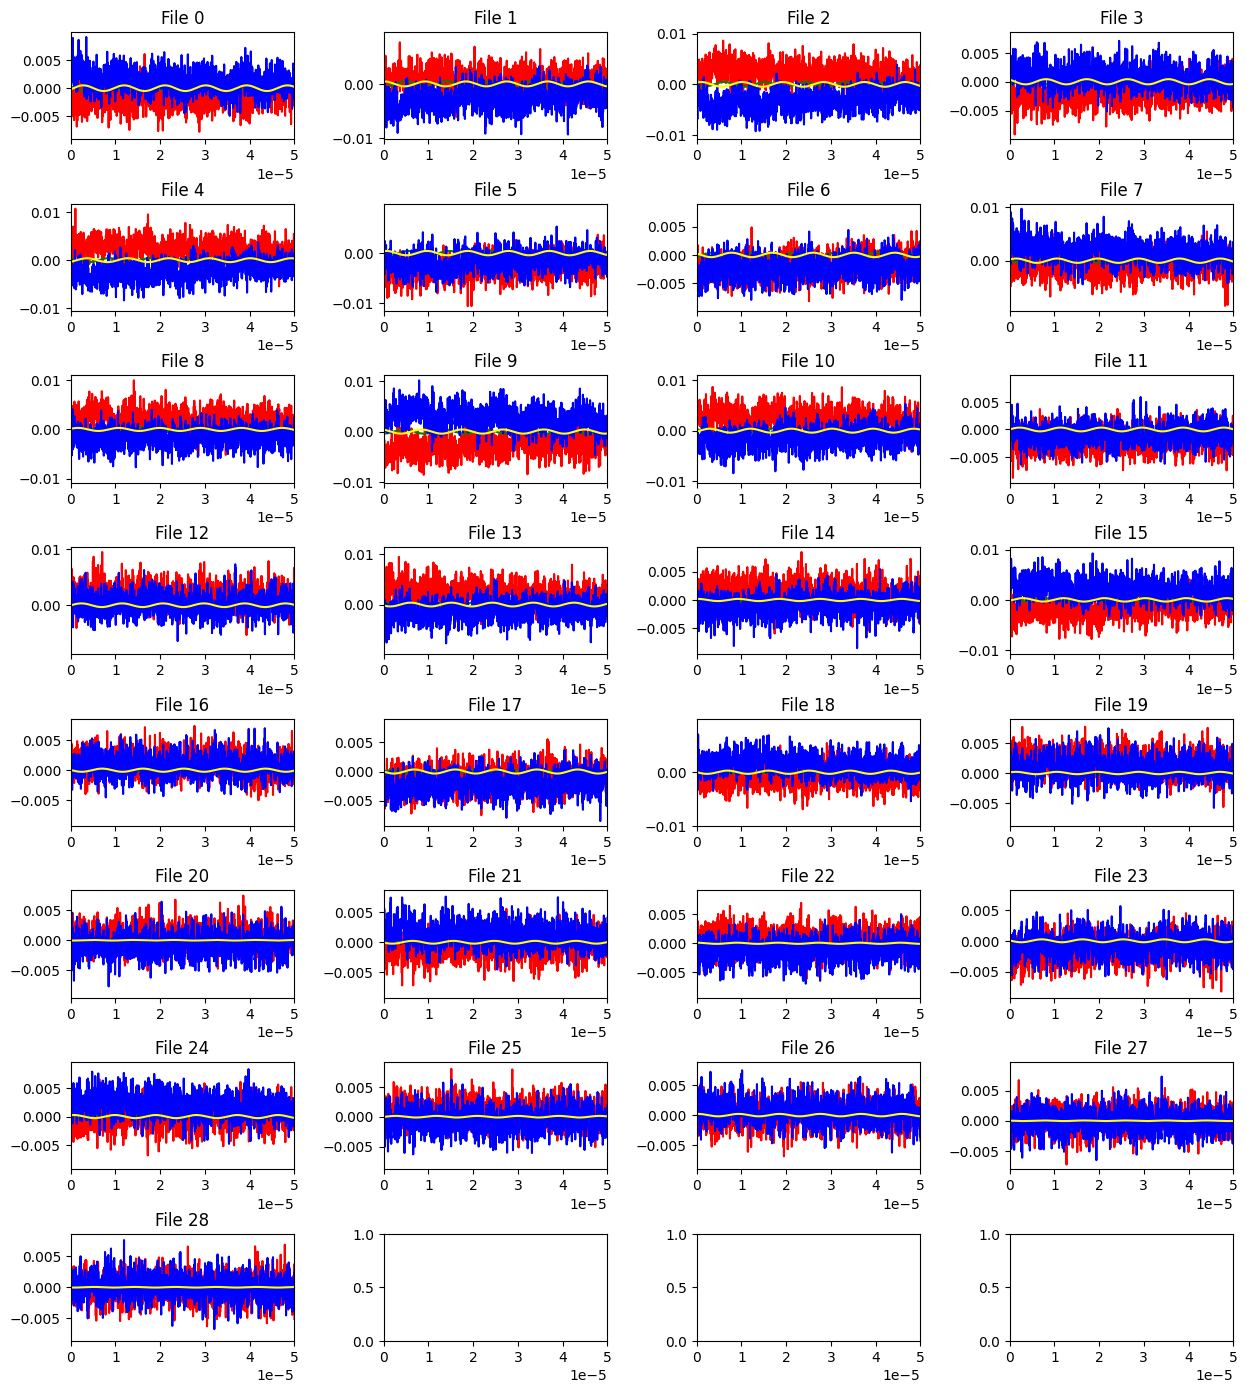

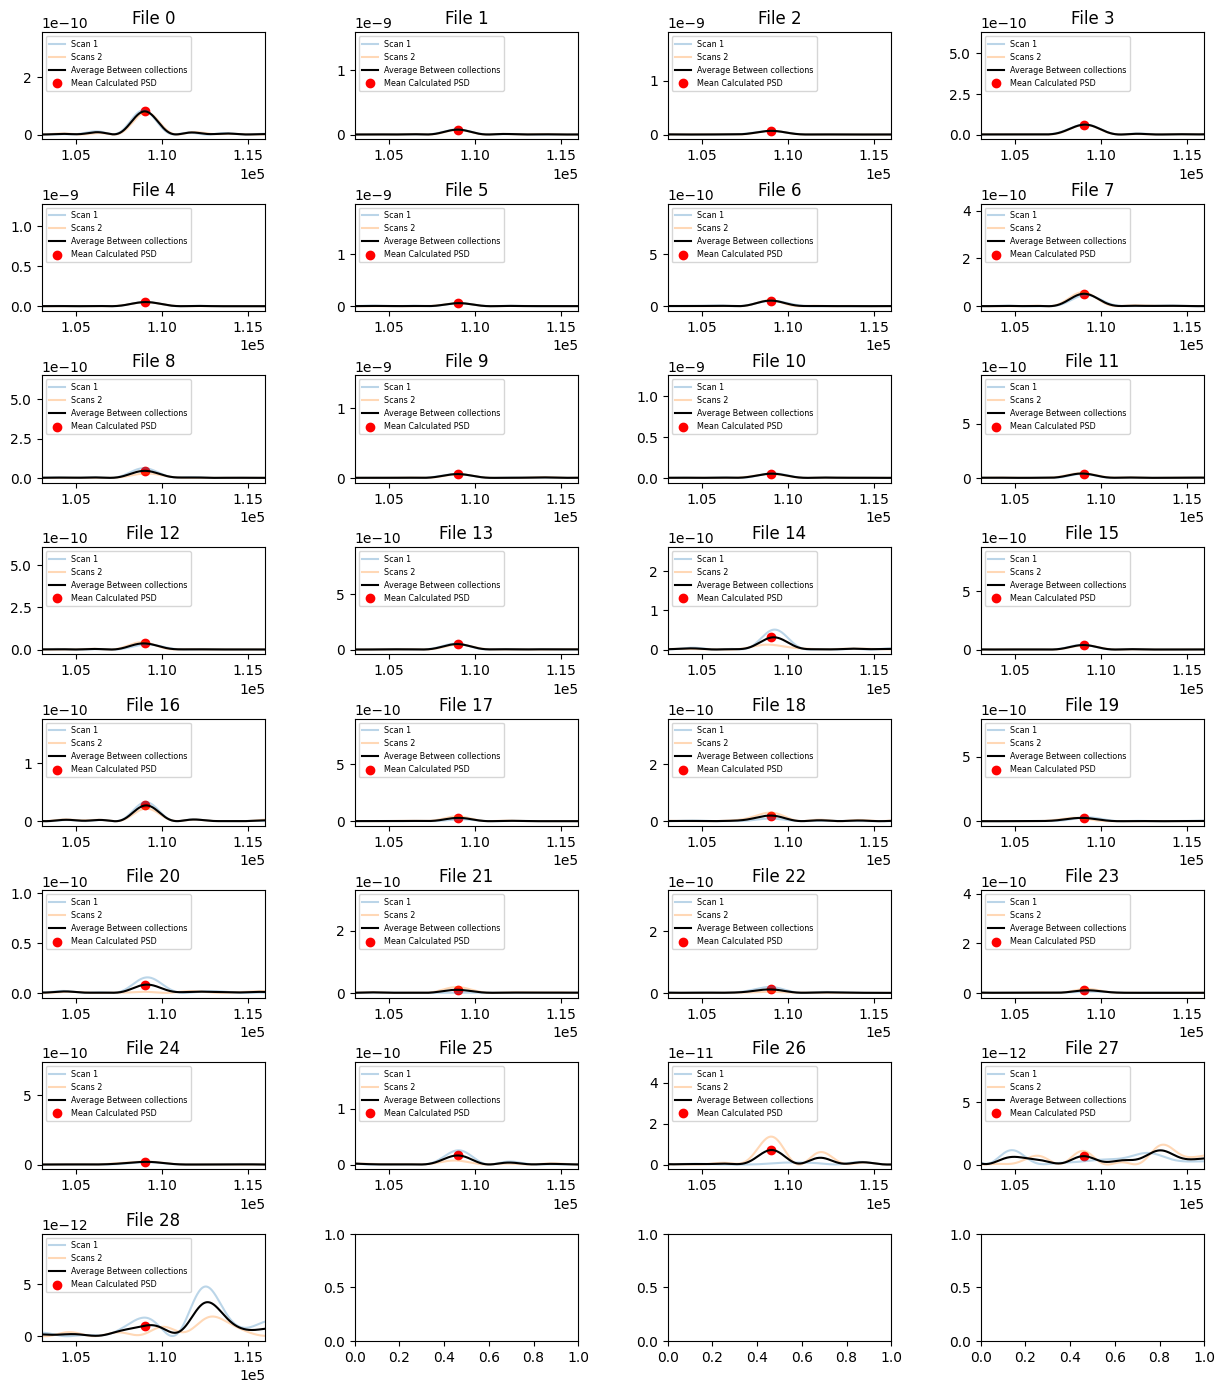

In [7]:
# creating appropriate number of subplots and empty arrays for data and fit psd (power spectral density)
fig, ax = plt.subplots(rows, 4, figsize = (15,17))
calc_psd = []
data_psd = []
amps = []

# for loop calculates a sine squared fit for every psd around f_avg Hz intensity signal (sine power reduction from 1.08e6)
# enumerate assigns i index to d data
for i, d in enumerate(piezo.get_data()):
    sig = 0 # placeholder for fitted signal 
    p = [] # power
    a=[] # amplitude of sine fit
    # applying time gate and linear detrend to piezo object  
    pp(piezo, d, i)

    # ax[][] picks the location for the subplot


    # each time-series has two collections, so must do this fitting processs twice
    # plots raw time-series psd for first scan in collection (each collection has two scans)
    ax[i//4][i % 4].plot(d.collection[0].t, d.collection[0].x, color = 'red') 
    
    ax[i//4][i % 4].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    #assigns least-squares fit to raw-data signal, initial guess: [amplitude, phase, offset]
    sig = fit(signal, d.collection[0].t, d.collection[0].x, [0.005, 0, 0]) #curve_fit returns a 2D array, parameters we want are in first imbedded array
    a.append(np.abs(sig[0][0]))
    p.append(sig[0][0] ** 2 / (f_avg / (2 * np.pi))) # converting to V^2 / Hz for psd
    # appending time series fit for amplitude and power
    amps.append(a)
    calc_psd.append(p)
     # plotting the fit
    ax[i//4][i % 4].plot(d.collection[0].t, signal(d.collection[0].t, sig[0][0], sig[0][1], sig[0][2]), color = 'green')


    
    
    # plotting time vs fit, sig[0][0], sig[0][1], sig[0][2] are the fitted amp, phase, and offset parameters
    
    ax[i//4][i % 4].set_title(f"File {usable_scans[i]}")

    #plots raw time-series psd for second scan in collection
    ax[i//4][i % 4].plot(d.collection[1].t, d.collection[1].x, color = 'blue')
    sig = fit(signal, d.collection[1].t, d.collection[1].x, [0.005, 0, 0])
    a.append(np.abs(sig[0][0]))
    p.append(sig[0][0] ** 2 / (f_avg / (2 * np.pi))) # converting to V^2 / Hz for psd
    # appending time series fit for amplitude and power
    amps.append(a)
    calc_psd.append(p)
    
    # again, plotting fitted signal for second collection scan 
    ax[i//4][i % 4].plot(d.collection[1].t, signal(d.collection[1].t, sig[0][0], sig[0][1], sig[0][2]), color = 'yellow')
    
    
for a in ax.flat:
    a.set_xlim(0, 5e-5)
plt.subplots_adjust(hspace=.6, wspace=0.4) # Manual control
calc_psd = np.array(calc_psd)

plt.show()

#--------------------------------------------------------------Plots for averages----------------------------------------------------------------------


fig, ax = plt.subplots(rows, 4, figsize = (15, 17))
calc_psd =[]
for i, d in enumerate(piezo.get_data()):
    pp(piezo, d, i)

    p = []

    # creating a periodogram for each collection
    f, x1 = periodogram(d.collection[0].x, piezo.get_data()[i].r, nfft = int(1e6))
    p.append(x1[find_idx(f, find_nearest(f, f_avg))])
    
    ax[i//4][i % 4].plot(f, x1, alpha = 0.3, label="Scan 1")
    ax[i//4][i % 4].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    avg = np.array(x1)


    f, x2 = periodogram(d.collection[1].x, piezo.get_data()[i].r, nfft = int(1e6))
    p.append(x2[find_idx(f, find_nearest(f,f_avg))])
    calc_psd.append(p)
    ax[i//4][i % 4].plot(f, x2, alpha = 0.3, label="Scans 2")
    avg = (avg + np.array(x2)) / 2
 
    ax[i//4][i % 4].plot(f, avg, c = "k", label="Average Between collections" )
    ax[i//4][i % 4].set_title(f"File {usable_scans[i]}")
    ax[i//4][i % 4].scatter(f_avg, np.mean(calc_psd[i]), c = "r", label="Mean Calculated PSD")
    ax[i//4][i % 4].set_xlim(1.03e5, 1.16e5)
    
    ax[i//4][i % 4].legend(fontsize="xx-small", loc='upper left')

data_psd = np.array(data_psd)
plt.subplots_adjust(hspace=.6, wspace=0.4) # Manual control
plt.show()

In [10]:
#---------------------------------------------------------------Calculation for max/min voltage-------------------------------------------------------
# peaks folder has scans where we are scanning the actuator through min and max points. Need to collect the absoltue min and max voltages 109kHz
minmax_scans = list(range(37))
minmax_rows = math.ceil(len(minmax_scans)/4) # for graphing subplots easier
# creating a piezo object, see System() class in analysis.py for details
minmax_piezo = syst(
    "minmax_piezo",
    [r"C:\Users\sl57562\The University of Texas at Austin\Acoustic + Calcium - Documents\Acoustic\Piezo_Characterization_Data_12-15-25\peaks/iter_"+str(x)+".tdms" for x in range(37)],
    #["/mnt/c/Users/Mitch/OneDrive - The University of Texas at Austin/Desktop/piezo_data/20251215/peaks/iter_"+str(x)+".tdms" for x in minmax_scans],
    channel="X",
    set_data=True
)
# confirming files in piezo object
#print(minmax_piezo.get_data())
#print(minmax_scans)


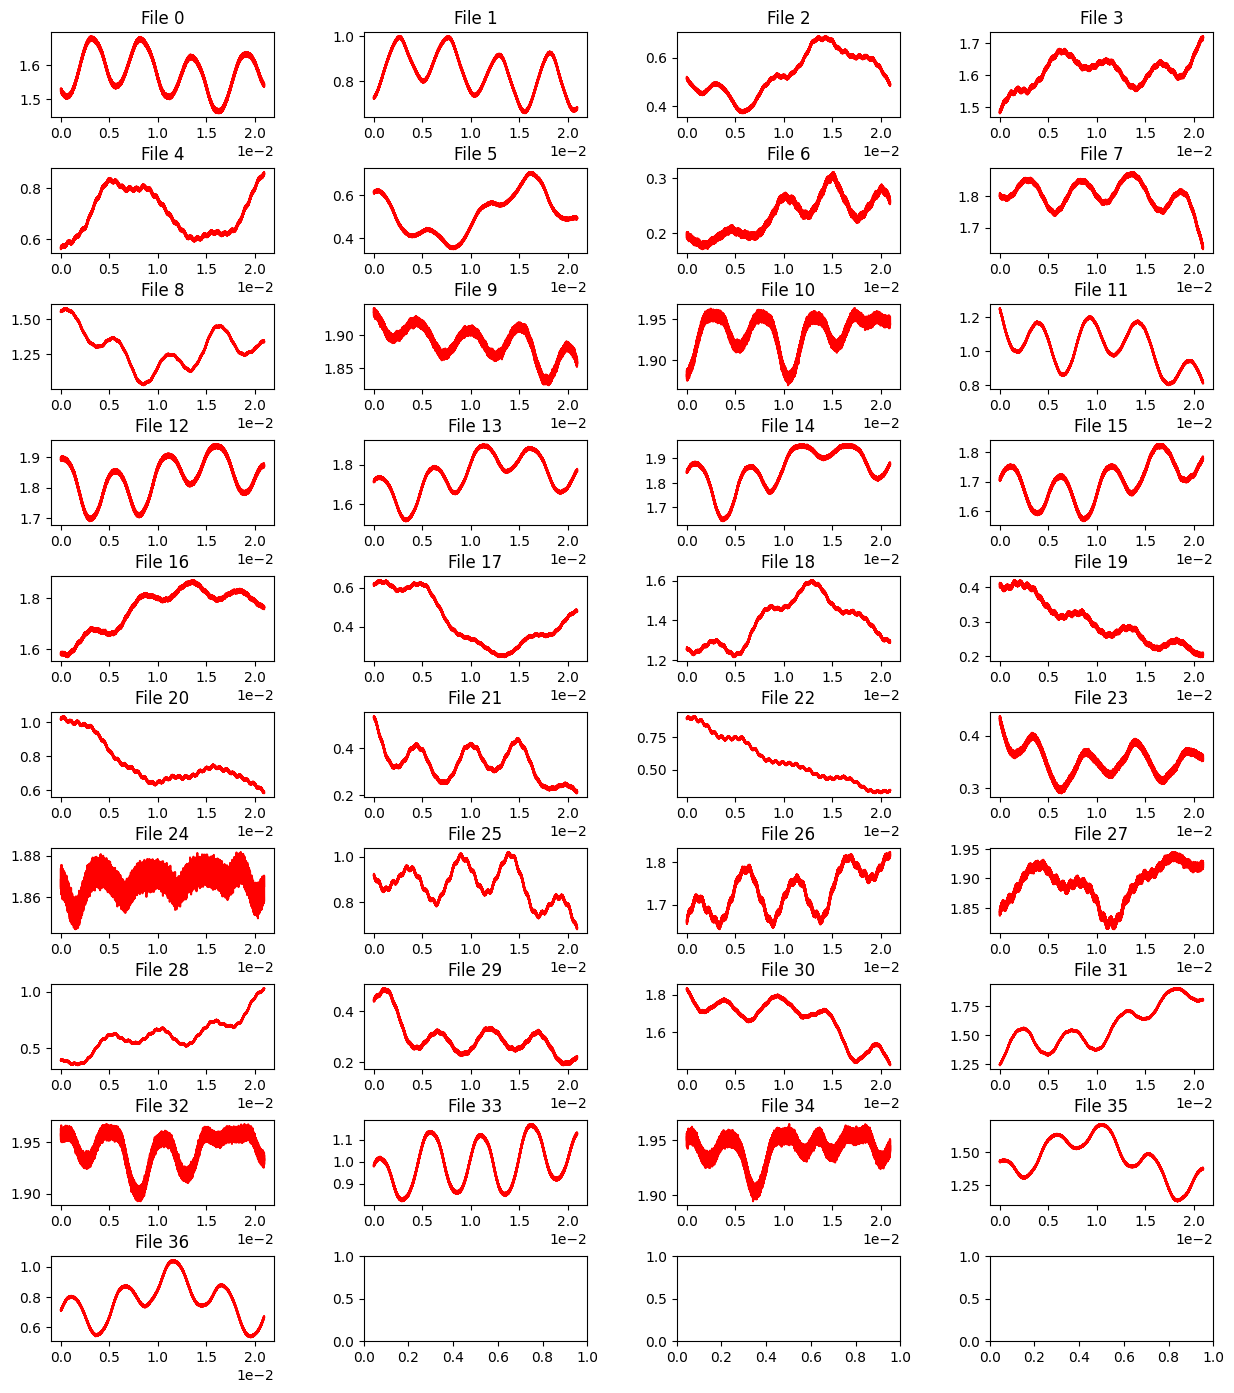

In [11]:
# creating appropriate number of subplots and empty arrays for data and fit psd (power spectral density)
fig, ax = plt.subplots(minmax_rows, 4, figsize = (15,17))


# for loop calculates a sine squared fit for every psd around f_avg Hz intensity signal (sine power reduction from 1.08e6)
# enumerate assigns i index to d data
for i, data in enumerate(minmax_piezo.get_data()):

    ax[i//4][i % 4].plot(data.collection[0].t, data.collection[0].x, color = 'red') 
    ax[i//4][i % 4].set_title(f"File {minmax_scans[i]}")
    ax[i//4][i % 4].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
  
plt.subplots_adjust(hspace=.6, wspace=0.4) # Manual control
calc_psd = np.array(calc_psd)

plt.show()

In [12]:
# find absolute max and min
stored_max = 0
stored_min = math.inf
for i, d in enumerate(minmax_piezo.get_data()):
    if stored_max < max(d.collection[0].x):
        stored_max = max(d.collection[0].x)
    if stored_min > min(d.collection[0].x):
        stored_min = min(d.collection[0].x)
   
# need to get avergae max and min voltage from peaks file, then apply the conversion with known wavelength and such

print(f"Absolute Max Voltage = {stored_max:.4f} V")  
print(f"Absolute Min Voltage = {stored_min:.4f} V")  
voltage_diff = stored_max - stored_min
wavelength_m = 1064e-9

Absolute Max Voltage = 1.9677 V
Absolute Min Voltage = 0.1703 V


Processing 1 Vpp data...
  -> Avg Amp: 0.0005 V | Stroke: 0.05 nm
Processing 2 Vpp data...
  -> Avg Amp: 0.0009 V | Stroke: 0.09 nm
Processing 3 Vpp data...
  -> Avg Amp: 0.0015 V | Stroke: 0.14 nm
Processing 4 Vpp data...
  -> Avg Amp: 0.0020 V | Stroke: 0.19 nm
Processing 5 Vpp data...
  -> Avg Amp: 0.0026 V | Stroke: 0.24 nm
Processing 6 Vpp data...
  -> Avg Amp: 0.0032 V | Stroke: 0.30 nm
Processing 7 Vpp data...
  -> Avg Amp: 0.0037 V | Stroke: 0.35 nm
Processing 8 Vpp data...
  -> Avg Amp: 0.0043 V | Stroke: 0.40 nm
Processing 9 Vpp data...
  -> Avg Amp: 0.0048 V | Stroke: 0.46 nm
Processing 10 Vpp data...
  -> Avg Amp: 0.0047 V | Stroke: 0.44 nm


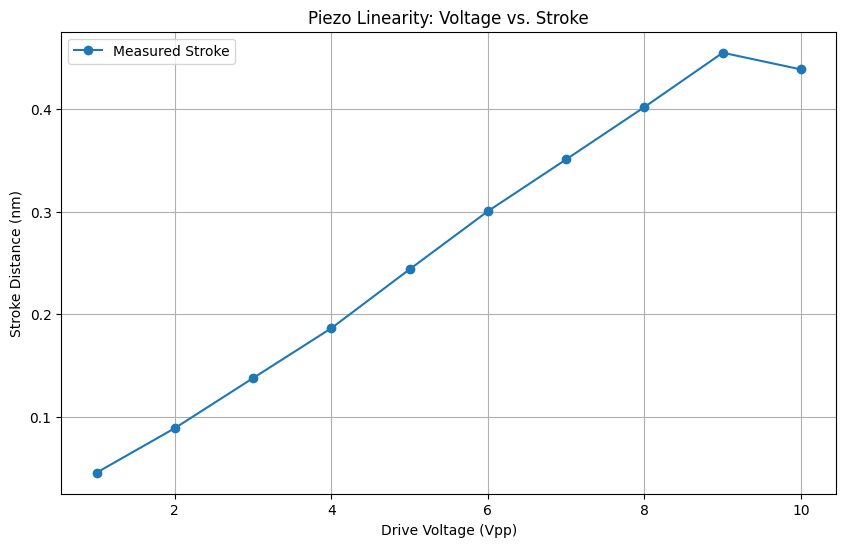

In [17]:
# automating the calculations configured in the above code, without graphing
voltages = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] # The Vpp folders you have
stroke_results = []
wavelength_m = 1064e-9  

# base path to scans 
base_path = r"C:\Users\sl57562\The University of Texas at Austin\Acoustic + Calcium - Documents\Acoustic\Piezo_Characterization_Data_12-15-25"

#"/mnt/c/Users/Mitch/OneDrive - The University of Texas at Austin/Desktop/piezo_data/20251215/"


for v in voltages:
    print(f"Processing {v} Vpp data...")
    
    # select the folder for specific voltage
    folder_name = f"stroke_dist_{v}vpp_109kHz"
    # file_paths = [f"{base_path}{folder_name}\iter_{x}.tdms" for x in range(29)]
    file_paths = [f"{base_path}\\stroke_dist_{v}vpp_109kHz\\iter_{x}.tdms" for x in range(29)]
    
    # make piezo object for each folder 
    # use a try/except block in case a specific voltage folder is missing or named differently
    try:
        current_piezo = syst("piezo", file_paths, channel="X", set_data=True)
    except Exception as e:
        print(f"Skipping {v}Vpp: Could not load files. Error: {e}")
        stroke_results.append(np.nan)
        continue

    # fit an get amplitudes 
    amps = []
    
    for i, d in enumerate(current_piezo.get_data()):
        # linear preprocessing
        pp(current_piezo, d, i)
        

        sig = fit(signal, d.collection[0].t, d.collection[0].x, [0.005, 0, 0])
        amps.append(np.abs(sig[0][0])) 

    # get average amplitude fit
    if amps:
        mean_amp = np.max(amps)
        # calculate the stroke distance with scaling formula and add to stroke results for graphing
        dist_meters = (wavelength_m * mean_amp) / (2*np.pi * voltage_diff)
        
        stroke_results.append(dist_meters)
        print(f"  -> Avg Amp: {mean_amp:.4f} V | Stroke: {dist_meters*1e9:.2f} nm")
    else:
        stroke_results.append(np.nan)


plt.figure(figsize=(10, 6))
plt.plot(voltages, [s * 1e9 for s in stroke_results], 'o-', label='Measured Stroke')
plt.xlabel('Drive Voltage (Vpp)')
plt.ylabel('Stroke Distance (nm)')
plt.title('Piezo Linearity: Voltage vs. Stroke')
plt.grid(True)
plt.legend()
plt.show()